# Decision Trees

---

## Table of Contents
1. [The Core Idea — Recursive Partitioning](#1-the-core-idea)
2. [Impurity Measures — Gini & Entropy](#2-impurity-measures)
3. [Information Gain & The Splitting Criterion](#3-information-gain)
4. [How a Split is Found — The Algorithm](#4-how-a-split-is-found)
5. [Regression Trees — Variance Reduction](#5-regression-trees)
6. [Tree Depth, Overfitting & Pruning](#6-overfitting--pruning)
7. [Feature Importance](#7-feature-importance)
8. [Decision Trees vs Linear Models](#8-decision-trees-vs-linear-models)

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from sklearn.datasets import load_iris, make_classification, make_regression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import os

os.makedirs('img', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444', 'axes.labelcolor': '#ccc',
    'xtick.color': '#888', 'ytick.color': '#888', 'text.color': '#eee',
    'grid.color': '#2a2a2a', 'grid.linewidth': 0.8,
    'font.family': 'monospace', 'axes.titlesize': 12, 'axes.labelsize': 11,
})
ACCENT = '#00e5ff'
ORANGE = '#ff6d00'
GREEN  = '#69ff47'
RED    = '#ff4d6d'
PURPLE = '#c77dff'
YELLOW = '#ffd60a'
WHITE  = '#eeeeee'

---
## 1. The Core Idea — Recursive Partitioning

A decision tree partitions the feature space into **axis-aligned rectangular regions**, assigning a single prediction to each region.

Given a dataset at node $t$ with $n_t$ samples, the algorithm:
1. Considers every possible split: every feature $j$ and every threshold $\tau$
2. Evaluates each split using an **impurity measure**
3. Picks the split that **maximally reduces impurity**
4. Recurses on the two resulting subsets
5. Stops when a stopping criterion is met (max depth, min samples, or pure node)

This is a **greedy algorithm** — it makes the locally optimal split at each node without backtracking. This means the globally optimal tree is not guaranteed, but in practice the greedy solution is good enough.

The prediction at each leaf:
- **Classification**: majority class of the samples in that leaf
- **Regression**: mean of the target values in that leaf

**Key insight**: the entire expressive power of a decision tree comes from where the splits are placed. The predictions themselves are trivial once the tree structure is fixed.

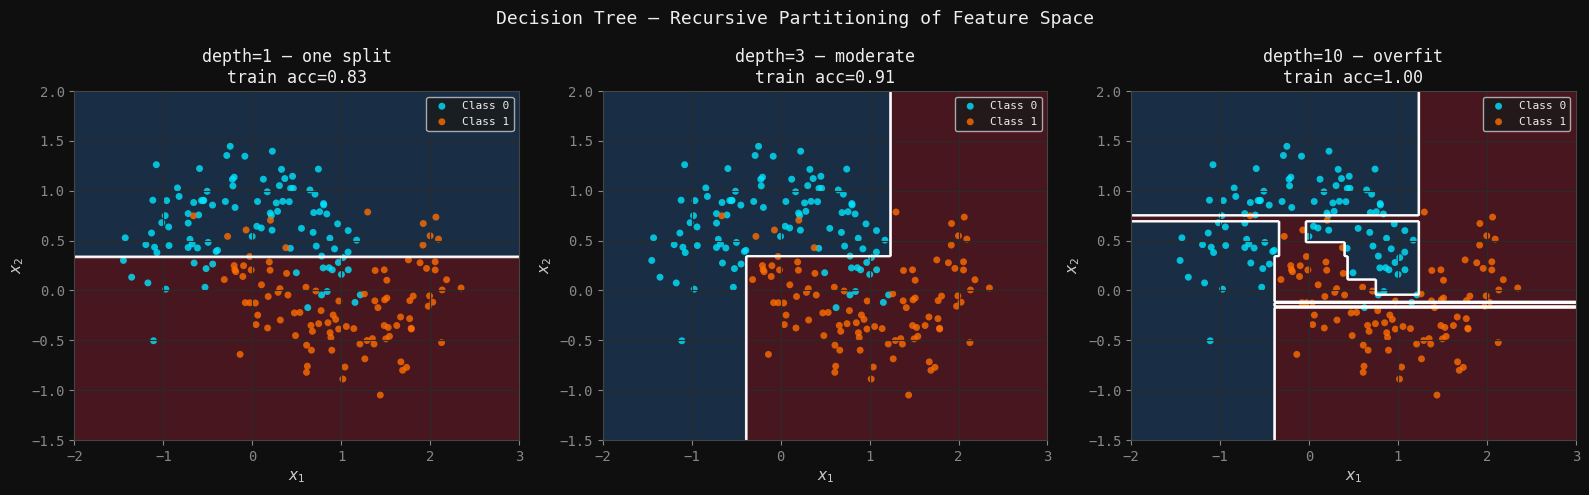

In [2]:
np.random.seed(0)
from sklearn.datasets import make_moons
X_demo, y_demo = make_moons(n_samples=200, noise=0.25, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Decision Tree — Recursive Partitioning of Feature Space', fontsize=13)

xx, yy = np.meshgrid(np.linspace(-2, 3, 300), np.linspace(-1.5, 2, 300))

for ax, depth, title in zip(axes,
                              [1, 3, 10],
                              ['depth=1 — one split', 'depth=3 — moderate', 'depth=10 — overfit']):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X_demo, y_demo)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.35, cmap='RdBu_r')
    ax.contour(xx,  yy, Z, colors='white', linewidths=1.0, alpha=0.6)
    ax.scatter(X_demo[y_demo==0, 0], X_demo[y_demo==0, 1],
               color=ACCENT, s=25, alpha=0.8, edgecolors='none', label='Class 0')
    ax.scatter(X_demo[y_demo==1, 0], X_demo[y_demo==1, 1],
               color=ORANGE, s=25, alpha=0.8, edgecolors='none', label='Class 1')
    train_acc = accuracy_score(y_demo, clf.predict(X_demo))
    ax.set_title(f'{title}\ntrain acc={train_acc:.2f}')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig('img/dt01_partitioning.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Impurity Measures — Gini & Entropy

At a node $t$ containing $n_t$ samples from $C$ classes, let $p_c$ be the **proportion** of class $c$:
$$p_c = \frac{|\{i \in t : y_i = c\}|}{n_t}$$

### Gini Impurity

$$G(t) = \sum_{c=1}^C p_c(1 - p_c) = 1 - \sum_{c=1}^C p_c^2$$

**Interpretation**: the probability that a randomly chosen sample is misclassified if we label it according to the class distribution at node $t$. If you pick a sample at random (probability $p_c$) and assign the wrong label (probability $1-p_c$), the expected error is $\sum_c p_c(1-p_c)$.

- $G = 0$: node is **pure** — all samples belong to one class
- $G = 1 - 1/C$: node is maximally **impure** — all classes equally represented ($p_c = 1/C$)
- For binary classification: $G = 2p(1-p)$, max at $p=0.5$: $G_{\max} = 0.5$

### Entropy (Shannon)

$$H(t) = -\sum_{c=1}^C p_c \log_2(p_c)$$

where $0 \log_2 0 = 0$ by convention.

**Interpretation**: average number of bits needed to encode the class label of a randomly drawn sample from node $t$.

- $H = 0$: pure node — no uncertainty, 0 bits needed
- $H = \log_2 C$: maximally impure — $\log_2 C$ bits needed
- For binary: $H_{\max} = 1$ bit at $p = 0.5$

### Gini vs Entropy — when does the choice matter?

Both produce nearly identical trees in practice. Entropy involves a logarithm (more expensive to compute) and penalises impurity slightly more at the extremes. Gini is the default in sklearn. Use entropy when you want to be closer to information-theoretic principles (ID3, C4.5 algorithms use entropy).

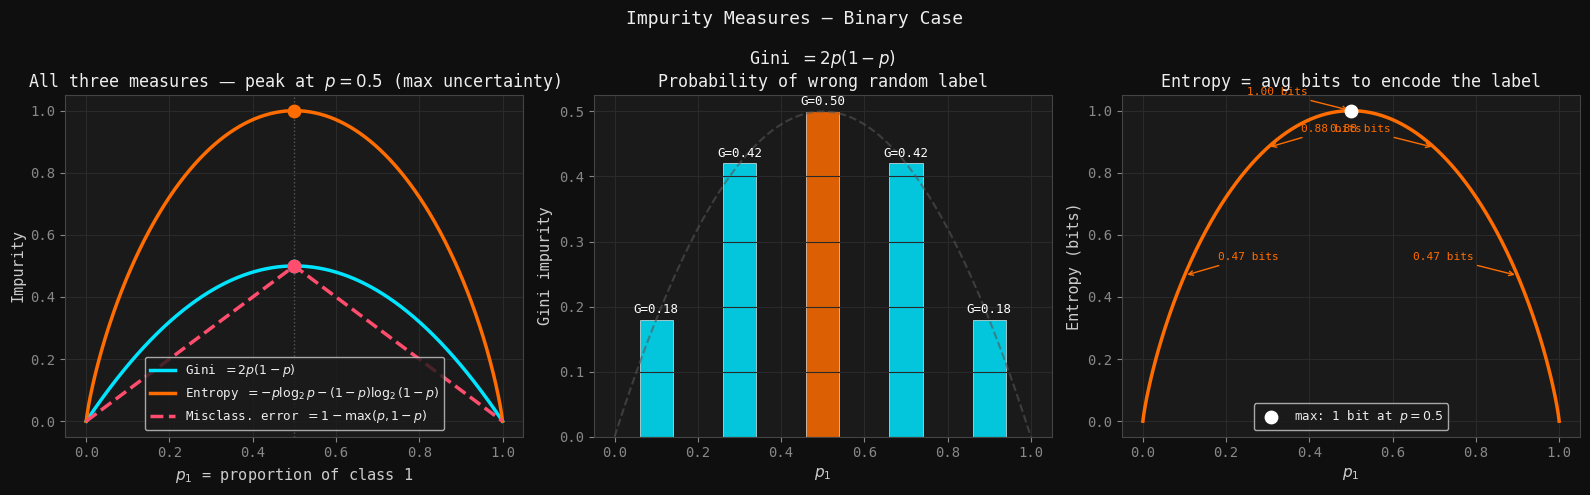

In [3]:
p = np.linspace(1e-9, 1 - 1e-9, 500)  # p = P(class=1) in binary case

gini    = 2 * p * (1 - p)
entropy = -(p * np.log2(p) + (1-p) * np.log2(1-p))
misclass = 1 - np.maximum(p, 1-p)  # misclassification error

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Impurity Measures — Binary Case', fontsize=13)

# All three on the same plot
ax = axes[0]
ax.plot(p, gini,     color=ACCENT,  lw=2.5, label='Gini $= 2p(1-p)$')
ax.plot(p, entropy,  color=ORANGE,  lw=2.5, label='Entropy $= -p\\log_2 p - (1-p)\\log_2(1-p)$')
ax.plot(p, misclass, color=RED,     lw=2.5, linestyle='--', label='Misclass. error $= 1 - \\max(p, 1-p)$')
ax.scatter([0.5], [0.5],  color=ACCENT,  s=80, zorder=5)
ax.scatter([0.5], [1.0],  color=ORANGE,  s=80, zorder=5)
ax.scatter([0.5], [0.5],  color=RED,     s=80, zorder=5)
ax.axvline(0.5, color='#555', lw=1, linestyle=':')
ax.set_xlabel('$p_1$ = proportion of class 1')
ax.set_ylabel('Impurity')
ax.set_title('All three measures — peak at $p=0.5$ (max uncertainty)')
ax.legend(fontsize=9); ax.grid(True)

# Gini: derivation visual
ax = axes[1]
p_vals_bar = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
g_vals     = 2 * p_vals_bar * (1 - p_vals_bar)
for pv, gv in zip(p_vals_bar, g_vals):
    bar_color = ORANGE if abs(pv - 0.5) < 0.05 else ACCENT
    ax.bar(pv, gv, width=0.08, color=bar_color, alpha=0.85,
           edgecolor='white', linewidth=0.5)
    ax.text(pv, gv + 0.01, f'G={gv:.2f}', ha='center', fontsize=9, color='white')
ax.plot(p, gini, color='#555', lw=1.5, linestyle='--', alpha=0.6)
ax.set_xlabel('$p_1$'); ax.set_ylabel('Gini impurity')
ax.set_title('Gini $= 2p(1-p)$\nProbability of wrong random label')
ax.grid(True)

# Entropy: bit interpretation
ax = axes[2]
ax.plot(p, entropy, color=ORANGE, lw=2.5)
for pv in [0.1, 0.3, 0.5, 0.7, 0.9]:
    hv = -(pv*np.log2(pv) + (1-pv)*np.log2(1-pv))
    ax.annotate(f'{hv:.2f} bits', xy=(pv, hv),
                xytext=(pv + (0.08 if pv < 0.5 else -0.25), hv + 0.05),
                color=ORANGE, fontsize=8,
                arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1))
ax.scatter([0.5], [1.0], color='white', s=80, zorder=5, label='max: 1 bit at $p=0.5$')
ax.set_xlabel('$p_1$'); ax.set_ylabel('Entropy (bits)')
ax.set_title('Entropy = avg bits to encode the label')
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig('img/dt02_impurity.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Information Gain & The Splitting Criterion

A split on feature $j$ at threshold $\tau$ divides node $t$ into left child $t_L$ and right child $t_R$:
$$t_L = \{i \in t : x_{ij} \leq \tau\}, \qquad t_R = \{i \in t : x_{ij} > \tau\}$$

### Information Gain (with Entropy)

$$\text{IG}(t, j, \tau) = H(t) - \left[\frac{n_{t_L}}{n_t} H(t_L) + \frac{n_{t_R}}{n_t} H(t_R)\right]$$

The weighted entropy of the children is the **conditional entropy** $H(Y | X_j \leq \tau)$. Information Gain is therefore:
$$\text{IG} = H(Y) - H(Y | X_j, \tau) \geq 0$$

IG is always non-negative (splitting can never increase average impurity) and equals 0 only if the split is useless.

### Gini Gain

The same idea with Gini instead of Entropy:
$$\Delta G(t, j, \tau) = G(t) - \left[\frac{n_{t_L}}{n_t} G(t_L) + \frac{n_{t_R}}{n_t} G(t_R)\right]$$

### Worked Example

Suppose a node has 10 samples: 6 class A, 4 class B. We try a split that puts [5A, 1B] left and [1A, 3B] right.

$$H(\text{parent}) = -\frac{6}{10}\log_2\frac{6}{10} - \frac{4}{10}\log_2\frac{4}{10} = 0.971 \text{ bits}$$

$$H(t_L) = -\frac{5}{6}\log_2\frac{5}{6} - \frac{1}{6}\log_2\frac{1}{6} = 0.650 \text{ bits}$$

$$H(t_R) = -\frac{1}{4}\log_2\frac{1}{4} - \frac{3}{4}\log_2\frac{3}{4} = 0.811 \text{ bits}$$

$$\text{IG} = 0.971 - \left[\frac{6}{10} \times 0.650 + \frac{4}{10} \times 0.811\right] = 0.971 - 0.714 = 0.257 \text{ bits}$$

### Why Gini often beats Entropy computationally

Gini $= 1 - \sum p_c^2$ requires only multiplications and additions. Entropy requires computing $\log_2(p_c)$ for every class — significantly slower for datasets with many classes.

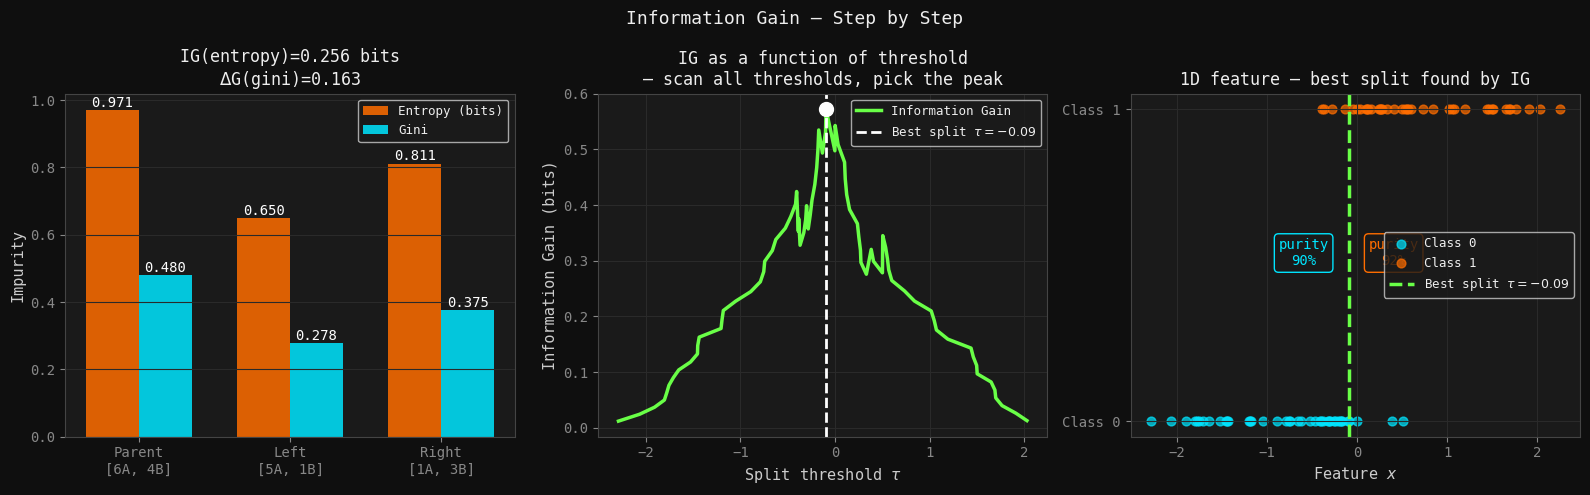

In [4]:
# Visualise information gain for the worked example
def entropy_fn(counts):
    counts = np.array(counts, dtype=float)
    total  = counts.sum()
    if total == 0: return 0
    probs  = counts[counts > 0] / total
    return -np.sum(probs * np.log2(probs))

def gini_fn(counts):
    counts = np.array(counts, dtype=float)
    total  = counts.sum()
    if total == 0: return 0
    probs = counts / total
    return 1 - np.sum(probs**2)

# Worked example
parent  = [6, 4]
left    = [5, 1]
right   = [1, 3]
n_par   = sum(parent)
n_l, n_r = sum(left), sum(right)

H_par = entropy_fn(parent)
H_l   = entropy_fn(left)
H_r   = entropy_fn(right)
IG    = H_par - (n_l/n_par * H_l + n_r/n_par * H_r)

G_par = gini_fn(parent)
G_l   = gini_fn(left)
G_r   = gini_fn(right)
DG    = G_par - (n_l/n_par * G_l + n_r/n_par * G_r)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Information Gain — Step by Step', fontsize=13)

# Worked example bar chart
ax = axes[0]
nodes   = ['Parent\n[6A, 4B]', 'Left\n[5A, 1B]', 'Right\n[1A, 3B]']
H_vals  = [H_par, H_l, H_r]
G_vals  = [G_par, G_l, G_r]
x_pos   = np.arange(3)
w = 0.35
bars_h = ax.bar(x_pos - w/2, H_vals, w, color=ORANGE, alpha=0.85, label='Entropy (bits)')
bars_g = ax.bar(x_pos + w/2, G_vals, w, color=ACCENT,  alpha=0.85, label='Gini')
for bars, vals in [(bars_h, H_vals), (bars_g, G_vals)]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', fontsize=10, color='white')
ax.set_xticks(x_pos); ax.set_xticklabels(nodes)
ax.set_ylabel('Impurity')
ax.set_title(f'IG(entropy)={IG:.3f} bits\n$\\Delta$G(gini)={DG:.3f}')
ax.legend(fontsize=9); ax.grid(True, axis='y')

# How IG changes as the split moves across a 1D feature
np.random.seed(7)
n_scan = 80
x_scan = np.sort(np.random.randn(n_scan))
y_scan = (x_scan + np.random.randn(n_scan)*0.3 > 0).astype(int)

thresholds_scan = np.unique(x_scan)[:-1]
ig_scan = []
for tau in thresholds_scan:
    left_mask  = x_scan <= tau
    right_mask = ~left_mask
    n_l_s = left_mask.sum(); n_r_s = right_mask.sum()
    if n_l_s == 0 or n_r_s == 0:
        ig_scan.append(0); continue
    H_p = entropy_fn([np.sum(y_scan==0), np.sum(y_scan==1)])
    H_lf = entropy_fn([np.sum(y_scan[left_mask]==0),  np.sum(y_scan[left_mask]==1)])
    H_rf = entropy_fn([np.sum(y_scan[right_mask]==0), np.sum(y_scan[right_mask]==1)])
    ig_scan.append(H_p - (n_l_s/n_scan*H_lf + n_r_s/n_scan*H_rf))

best_tau_idx = np.argmax(ig_scan)
best_tau     = thresholds_scan[best_tau_idx]

ax = axes[1]
ax.plot(thresholds_scan, ig_scan, color=GREEN, lw=2.5, label='Information Gain')
ax.axvline(best_tau, color='white', lw=2, linestyle='--',
           label=f'Best split $\\tau={best_tau:.2f}$')
ax.scatter(best_tau, ig_scan[best_tau_idx], color='white', s=100, zorder=5)
ax.set_xlabel('Split threshold $\\tau$')
ax.set_ylabel('Information Gain (bits)')
ax.set_title('IG as a function of threshold\n— scan all thresholds, pick the peak')
ax.legend(fontsize=9); ax.grid(True)

# Scatter with best split
ax = axes[2]
ax.scatter(x_scan[y_scan==0], np.zeros(np.sum(y_scan==0)),
           color=ACCENT, s=40, alpha=0.7, label='Class 0')
ax.scatter(x_scan[y_scan==1], np.ones(np.sum(y_scan==1)),
           color=ORANGE, s=40, alpha=0.7, label='Class 1')
ax.axvline(best_tau, color=GREEN, lw=2.5, linestyle='--',
           label=f'Best split $\\tau={best_tau:.2f}$')
# Show purity of each side
lm = x_scan <= best_tau; rm = ~lm
purity_l = max(np.mean(y_scan[lm]==0), np.mean(y_scan[lm]==1))
purity_r = max(np.mean(y_scan[rm]==0), np.mean(y_scan[rm]==1))
ax.text(best_tau - 0.5, 0.5, f'purity\n{purity_l:.0%}', ha='center',
        color=ACCENT, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='#1a1a1a', edgecolor=ACCENT))
ax.text(best_tau + 0.5, 0.5, f'purity\n{purity_r:.0%}', ha='center',
        color=ORANGE, fontsize=10,
        bbox=dict(boxstyle='round', facecolor='#1a1a1a', edgecolor=ORANGE))
ax.set_xlabel('Feature $x$'); ax.set_yticks([0,1]); ax.set_yticklabels(['Class 0','Class 1'])
ax.set_title('1D feature — best split found by IG')
ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig('img/dt03_information_gain.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. How a Split is Found — The Algorithm

For a node with $n_t$ samples and $p$ features, the split search algorithm:

```
For each feature j = 1..p:
    Sort samples by x_j  →  O(n_t log n_t)
    For each consecutive pair (candidate threshold):
        Compute impurity of left and right child
        Record IG
Pick (j*, τ*) = argmax IG
```

**Complexity per node**: $\mathcal{O}(p \cdot n_t \log n_t)$

**Total training complexity**: $\mathcal{O}(p \cdot n \log^2 n)$ for a balanced tree of depth $\log n$

### Candidate thresholds

For a feature with $n_t$ distinct values, there are $n_t - 1$ candidate split points — the **midpoints** between consecutive sorted values. Only these midpoints need to be evaluated; no split between two samples of the same class can improve impurity.

### Efficient impurity updates (the increment trick)

Instead of recomputing $H(t_L)$ and $H(t_R)$ from scratch for each threshold, we can **update incrementally** as we scan:
- Move one sample from right to left
- Update the class counts in $\mathcal{O}(1)$
- Recompute $G$ or $H$ in $\mathcal{O}(C)$

This reduces per-feature cost from $\mathcal{O}(n_t^2)$ to $\mathcal{O}(n_t \cdot C)$ after sorting.

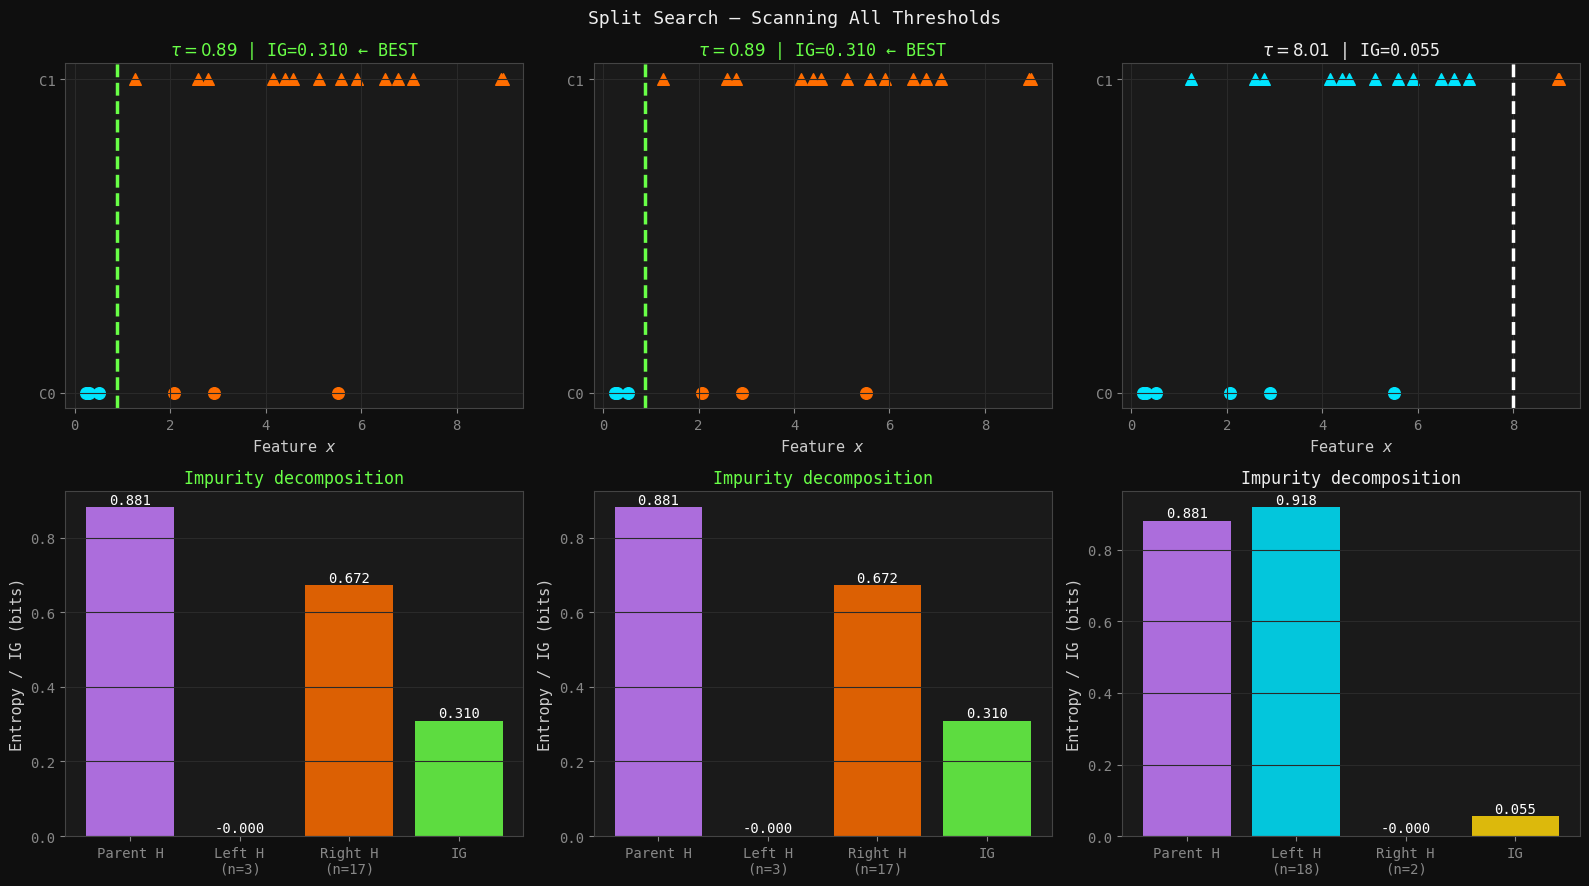

In [5]:
# Visualise the incremental scan for finding the best split
np.random.seed(3)
n_alg = 20
x_alg = np.sort(np.random.uniform(0, 10, n_alg))
y_alg = np.array([0,0,0,1,0,1,1,0,1,1,1,1,0,1,1,1,1,1,1,1])

thresholds_alg = (x_alg[:-1] + x_alg[1:]) / 2
igs_alg = []

for tau in thresholds_alg:
    lm = x_alg <= tau; rm = ~lm
    nl, nr = lm.sum(), rm.sum()
    H_p = entropy_fn([np.sum(y_alg==0), np.sum(y_alg==1)])
    Hl  = entropy_fn([np.sum(y_alg[lm]==0), np.sum(y_alg[lm]==1)])
    Hr  = entropy_fn([np.sum(y_alg[rm]==0), np.sum(y_alg[rm]==1)])
    igs_alg.append(H_p - (nl/n_alg*Hl + nr/n_alg*Hr))

best_idx_alg  = np.argmax(igs_alg)
best_tau_alg  = thresholds_alg[best_idx_alg]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Split Search — Scanning All Thresholds', fontsize=13)

for step_idx, ax_top, ax_bot in zip(
    [2, best_idx_alg, n_alg-3],
    axes[0], axes[1]):

    tau_step = thresholds_alg[step_idx]
    lm_s = x_alg <= tau_step; rm_s = ~lm_s
    nl_s, nr_s = lm_s.sum(), rm_s.sum()

    H_p  = entropy_fn([np.sum(y_alg==0),        np.sum(y_alg==1)])
    Hl_s = entropy_fn([np.sum(y_alg[lm_s]==0),  np.sum(y_alg[lm_s]==1)])
    Hr_s = entropy_fn([np.sum(y_alg[rm_s]==0),  np.sum(y_alg[rm_s]==1)])
    ig_s = H_p - (nl_s/n_alg*Hl_s + nr_s/n_alg*Hr_s)
    is_best = (step_idx == best_idx_alg)

    # Top: sample scatter with split line
    ax_top.scatter(x_alg[lm_s & (y_alg==0)], np.zeros(np.sum(lm_s & (y_alg==0))),
                   color=ACCENT, s=70, marker='o', label='Left, C0')
    ax_top.scatter(x_alg[lm_s & (y_alg==1)], np.ones(np.sum(lm_s & (y_alg==1))),
                   color=ACCENT, s=70, marker='^', label='Left, C1')
    ax_top.scatter(x_alg[rm_s & (y_alg==0)], np.zeros(np.sum(rm_s & (y_alg==0))),
                   color=ORANGE, s=70, marker='o', label='Right, C0')
    ax_top.scatter(x_alg[rm_s & (y_alg==1)], np.ones(np.sum(rm_s & (y_alg==1))),
                   color=ORANGE, s=70, marker='^', label='Right, C1')
    line_color = GREEN if is_best else 'white'
    ax_top.axvline(tau_step, color=line_color, lw=2.5, linestyle='--')
    title_color = GREEN if is_best else WHITE
    ax_top.set_title(f'$\\tau={tau_step:.2f}$ | IG={ig_s:.3f}' +
                     (' ← BEST' if is_best else ''),
                     color=title_color)
    ax_top.set_yticks([0,1]); ax_top.set_yticklabels(['C0','C1'])
    ax_top.set_xlabel('Feature $x$'); ax_top.grid(True)

    # Bottom: impurity breakdown
    bars_data  = [H_p, Hl_s, Hr_s, ig_s]
    bars_label = ['Parent H', f'Left H\n(n={nl_s})', f'Right H\n(n={nr_s})', 'IG']
    bars_color = [PURPLE, ACCENT, ORANGE, GREEN if is_best else YELLOW]
    b = ax_bot.bar(bars_label, bars_data, color=bars_color, alpha=0.85)
    for bar, val in zip(b, bars_data):
        ax_bot.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                    f'{val:.3f}', ha='center', fontsize=10, color='white')
    ax_bot.set_ylabel('Entropy / IG (bits)')
    ax_bot.set_title('Impurity decomposition', color=title_color)
    ax_bot.grid(True, axis='y')

plt.tight_layout()
plt.savefig('img/dt04_split_search.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Regression Trees — Variance Reduction

For regression, the target $y$ is continuous. We replace entropy/Gini with **variance** as the impurity measure.

### Node impurity

The impurity at node $t$ is the **mean squared deviation** from the node's prediction $\bar{y}_t$:

$$\text{Var}(t) = \frac{1}{n_t}\sum_{i \in t}(y_i - \bar{y}_t)^2$$

where $\bar{y}_t = \frac{1}{n_t}\sum_{i \in t} y_i$ is the mean — and also the **prediction** for any sample reaching leaf $t$.

### Variance Reduction (the split criterion)

$$\text{VR}(t, j, \tau) = \text{Var}(t) - \left[\frac{n_{t_L}}{n_t} \text{Var}(t_L) + \frac{n_{t_R}}{n_t} \text{Var}(t_R)\right]$$

### Why variance = MSE

At a leaf, we predict $\hat{y} = \bar{y}_t$. The training MSE on that leaf is:

$$\text{MSE}(t) = \frac{1}{n_t}\sum_{i \in t}(y_i - \bar{y}_t)^2 = \text{Var}(t)$$

So minimising leaf variance is exactly minimising training MSE. The split that maximally reduces variance is the one that would maximally reduce the training MSE if we stopped growing the tree right there.

### Efficient computation

Variance can be updated incrementally using the identity:
$$\text{Var}(t) = \overline{y^2}_t - \bar{y}_t^2$$

where $\overline{y^2}_t = \frac{1}{n_t}\sum y_i^2$. Both $\sum y_i$ and $\sum y_i^2$ update in $\mathcal{O}(1)$ as we move one sample.

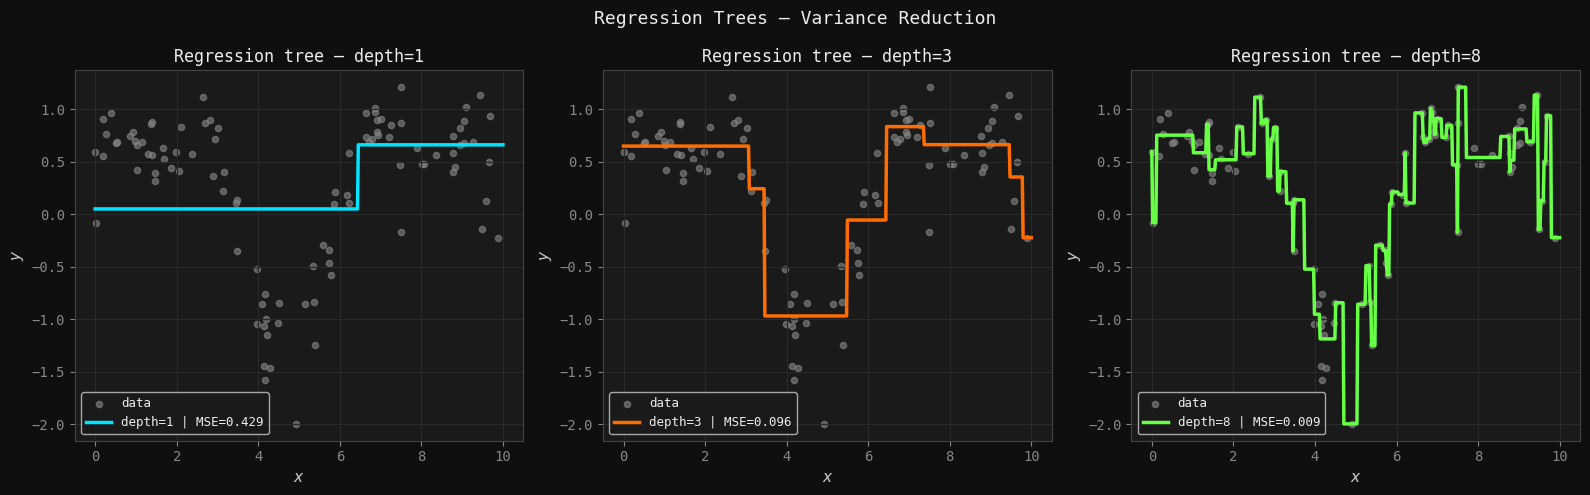

In [6]:
np.random.seed(1)
x_reg = np.sort(np.random.uniform(0, 10, 100))
y_reg = np.sin(x_reg) + 0.5*np.cos(2*x_reg) + np.random.randn(100)*0.3

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Regression Trees — Variance Reduction', fontsize=13)

# Different depths
for ax, depth, color, title in zip(
    axes,
    [1, 3, 8],
    [ACCENT, ORANGE, GREEN],
    ['depth=1', 'depth=3', 'depth=8']):

    X_r = x_reg.reshape(-1,1)
    reg = DecisionTreeRegressor(max_depth=depth).fit(X_r, y_reg)
    x_plot = np.linspace(0, 10, 500).reshape(-1,1)
    y_plot  = reg.predict(x_plot)
    mse = np.mean((y_reg - reg.predict(X_r))**2)
    ax.scatter(x_reg, y_reg, color='#888', s=20, alpha=0.6, label='data')
    ax.plot(x_plot, y_plot, color=color, lw=2.5, label=f'{title} | MSE={mse:.3f}')
    ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
    ax.set_title(f'Regression tree — {title}')
    ax.legend(fontsize=9); ax.grid(True)

plt.tight_layout()
plt.savefig('img/dt05_regression_tree.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Overfitting & Pruning

A fully grown tree memorises the training data — it creates one leaf per sample. This is **perfect training accuracy and terrible generalisation**.

### Stopping Criteria (pre-pruning)

| Parameter | What it does |
|-----------|-------------|
| `max_depth` | Hard cap on tree depth |
| `min_samples_split` | Node must have $\geq k$ samples to be split further |
| `min_samples_leaf` | Each resulting child must have $\geq k$ samples |
| `min_impurity_decrease` | Split only if $\Delta G \geq \epsilon$ |

### Cost-Complexity Pruning (post-pruning)

Grow the full tree, then prune branches that don't justify their complexity. Define the **cost-complexity criterion**:

$$R_\alpha(T) = \underbrace{R(T)}_{\text{training error}} + \underbrace{\alpha \cdot |T|}_{\text{complexity penalty}}$$

where $|T|$ is the number of leaves and $\alpha \geq 0$ is the complexity parameter (sklearn: `ccp_alpha`).

As $\alpha$ increases, the optimal tree shrinks — equivalent to adding a "cost" per leaf that forces the tree to justify each additional split in terms of training error reduction.

The **effective $\alpha$** of a subtree rooted at node $t$ is the $\alpha$ at which pruning $t$ becomes optimal:
$$\alpha_\text{eff}(t) = \frac{R(t) - R(T_t)}{|T_t| - 1}$$

where $R(t)$ is the error if $t$ is a leaf and $R(T_t)$ is the error of the full subtree rooted at $t$.

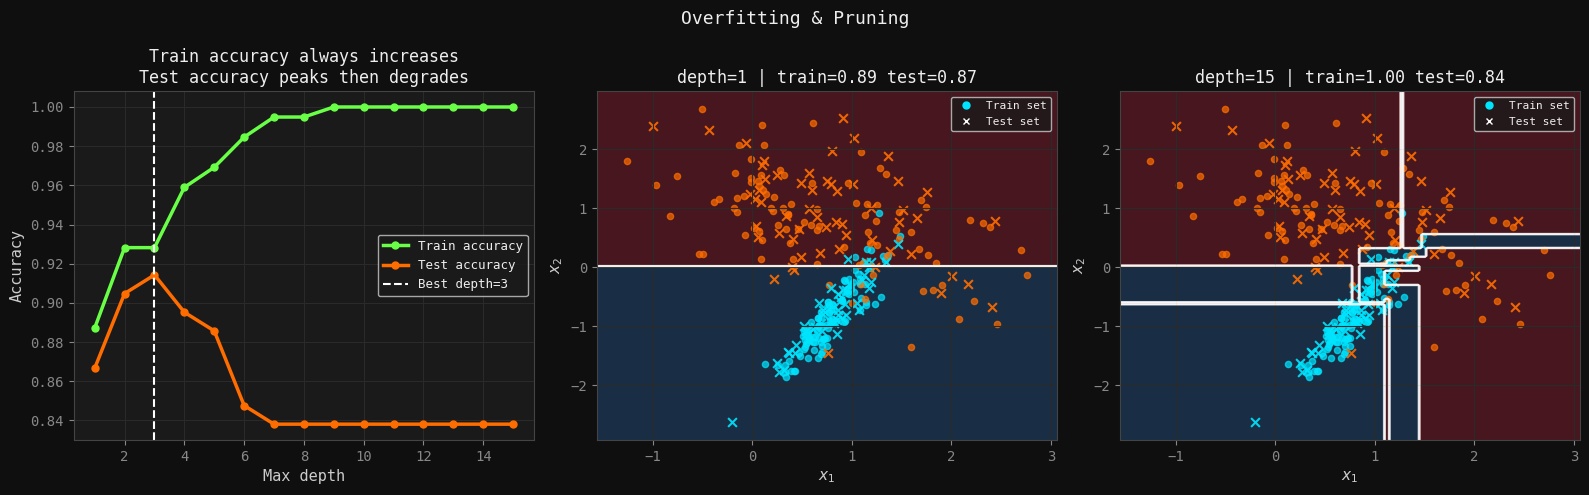

In [7]:
np.random.seed(42)
X_ov, y_ov = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                    n_informative=2, n_clusters_per_class=1,
                                    class_sep=0.8, random_state=42)
X_tr_ov, X_te_ov, y_tr_ov, y_te_ov = train_test_split(X_ov, y_ov, test_size=0.35, random_state=0)

depths = list(range(1, 16))
train_accs, test_accs = [], []
for d in depths:
    clf_d = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_tr_ov, y_tr_ov)
    train_accs.append(accuracy_score(y_tr_ov, clf_d.predict(X_tr_ov)))
    test_accs.append(accuracy_score(y_te_ov,  clf_d.predict(X_te_ov)))

best_depth = depths[np.argmax(test_accs)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Overfitting & Pruning', fontsize=13)

# Train vs test accuracy
ax = axes[0]
ax.plot(depths, train_accs, color=GREEN,  lw=2.5, marker='o', ms=5, label='Train accuracy')
ax.plot(depths, test_accs,  color=ORANGE, lw=2.5, marker='o', ms=5, label='Test accuracy')
ax.axvline(best_depth, color='white', lw=1.5, linestyle='--', label=f'Best depth={best_depth}')
ax.set_xlabel('Max depth'); ax.set_ylabel('Accuracy')
ax.set_title('Train accuracy always increases\nTest accuracy peaks then degrades')
ax.legend(fontsize=9); ax.grid(True)

# Decision boundaries: underfitting vs best vs overfit
xx_ov, yy_ov = np.meshgrid(np.linspace(X_ov[:,0].min()-0.3, X_ov[:,0].max()+0.3, 200),
                              np.linspace(X_ov[:,1].min()-0.3, X_ov[:,1].max()+0.3, 200))
for ax, depth in zip(axes[1:], [1, 15]):
    clf_d = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X_tr_ov, y_tr_ov)
    Z_ov = clf_d.predict(np.c_[xx_ov.ravel(), yy_ov.ravel()]).reshape(xx_ov.shape)
    ax.contourf(xx_ov, yy_ov, Z_ov, alpha=0.35, cmap='RdBu_r')
    ax.contour(xx_ov,  yy_ov, Z_ov, colors='white', linewidths=0.8, alpha=0.5)
    ax.scatter(X_tr_ov[y_tr_ov==0,0], X_tr_ov[y_tr_ov==0,1], color=ACCENT, s=20, alpha=0.7)
    ax.scatter(X_tr_ov[y_tr_ov==1,0], X_tr_ov[y_tr_ov==1,1], color=ORANGE, s=20, alpha=0.7)
    ax.scatter(X_te_ov[y_te_ov==0,0], X_te_ov[y_te_ov==0,1], color=ACCENT, s=40, marker='x', alpha=0.9)
    ax.scatter(X_te_ov[y_te_ov==1,0], X_te_ov[y_te_ov==1,1], color=ORANGE, s=40, marker='x', alpha=0.9)
    tr_a = accuracy_score(y_tr_ov, clf_d.predict(X_tr_ov))
    te_a = accuracy_score(y_te_ov, clf_d.predict(X_te_ov))
    ax.set_title(f'depth={depth} | train={tr_a:.2f} test={te_a:.2f}')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)
    ax.plot([], [], color=ACCENT,  marker='o', ms=5, linestyle='None', label='Train set')
    ax.plot([], [], color='white', marker='x', ms=5, linestyle='None', label='Test set')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('img/dt06_overfitting.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Feature Importance

Decision trees naturally produce a **feature importance score** as a by-product of training.

### Impurity-based importance (Mean Decrease in Impurity — MDI)

The importance of feature $j$ is the **total impurity reduction** it contributes across all splits in the tree, weighted by the number of samples reaching each split:

$$\text{importance}(j) = \sum_{t \,:\, \text{split on } j} \frac{n_t}{n} \cdot \Delta \text{Imp}(t)$$

where $\Delta \text{Imp}(t)$ is the impurity reduction at node $t$ and $n$ is total training samples.

The importances are then **normalised** to sum to 1.

### Caveats of MDI

- **High-cardinality features are favoured**: a feature with many distinct values has more candidate thresholds → more chances to find a good split by chance
- **Training-set statistic**: it measures how much the feature helped reduce training impurity, not generalisation
- **Correlated features split importance**: if two features are perfectly correlated, each gets ~half the importance even though either alone would suffice

### Permutation importance (more reliable)

For each feature $j$: permute its values in the **test set**, measure the increase in test error. This directly measures the feature's contribution to generalisation, not training impurity.

C:\Users\Tangu\AppData\Local\Temp\ipykernel_48268\1653742326.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


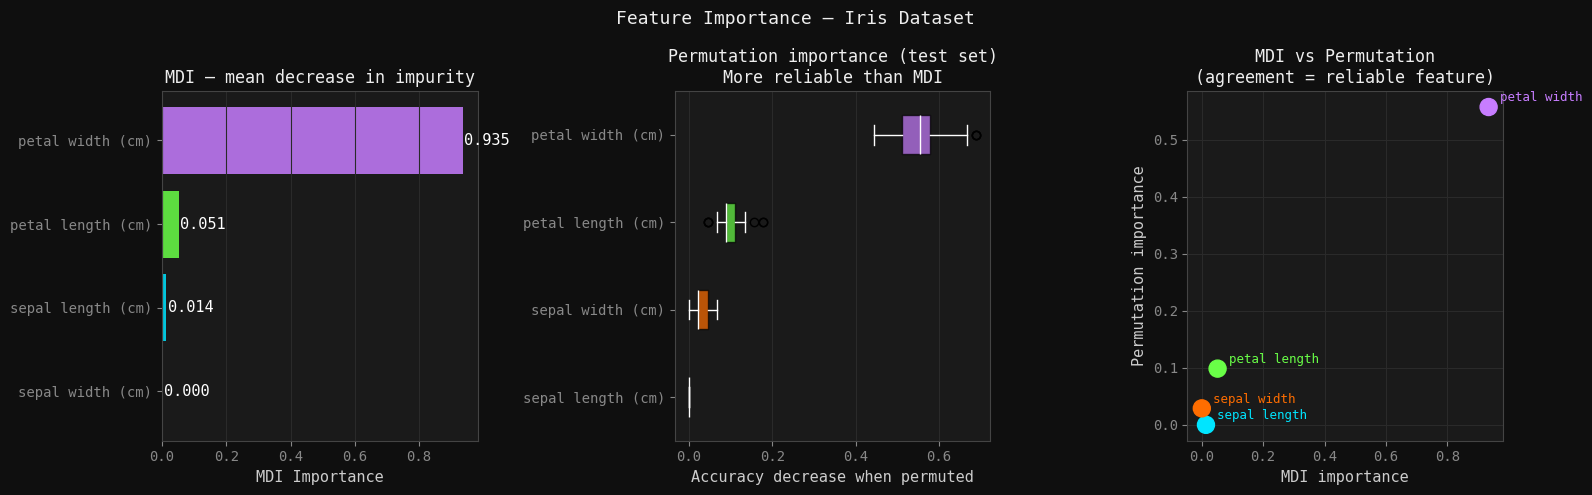

In [8]:
from sklearn.inspection import permutation_importance

np.random.seed(0)
iris = load_iris()
X_ir, y_ir = iris.data, iris.target
feat_names = iris.feature_names

clf_ir = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_ir, y_ir)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature Importance — Iris Dataset', fontsize=13)

# MDI importance
ax = axes[0]
mdi = clf_ir.feature_importances_
sorted_idx = np.argsort(mdi)
colors_imp = [ACCENT, ORANGE, GREEN, PURPLE]
bars = ax.barh([feat_names[i] for i in sorted_idx],
               mdi[sorted_idx], color=[colors_imp[i] for i in sorted_idx], alpha=0.85)
for bar, val in zip(bars, mdi[sorted_idx]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, color='white')
ax.set_xlabel('MDI Importance'); ax.set_title('MDI — mean decrease in impurity')
ax.grid(True, axis='x')

# Permutation importance
ax = axes[1]
X_tr_ir, X_te_ir, y_tr_ir, y_te_ir = train_test_split(X_ir, y_ir, test_size=0.3, random_state=0)
clf_ir2 = DecisionTreeClassifier(max_depth=4, random_state=0).fit(X_tr_ir, y_tr_ir)
result = permutation_importance(clf_ir2, X_te_ir, y_te_ir, n_repeats=30, random_state=0)
sorted_idx2 = np.argsort(result.importances_mean)
bp = ax.boxplot(
    [result.importances[i] for i in sorted_idx2],
    vert=False,
    labels=[feat_names[i] for i in sorted_idx2],
    patch_artist=True
)
for patch, i in zip(bp['boxes'], sorted_idx2):
    patch.set_facecolor(colors_imp[i])
    patch.set_alpha(0.7)
for element in ['whiskers','caps','medians','fliers']:
    for item in bp[element]:
        item.set_color('white')
ax.set_xlabel('Accuracy decrease when permuted')
ax.set_title('Permutation importance (test set)\nMore reliable than MDI')
ax.grid(True, axis='x')

# MDI vs Permutation comparison
ax = axes[2]
ax.scatter(mdi, result.importances_mean, color=[colors_imp[i] for i in range(4)],
           s=150, zorder=5)
for i, name in enumerate(feat_names):
    ax.annotate(name.replace(' (cm)', ''),
                xy=(mdi[i], result.importances_mean[i]),
                xytext=(8, 4), textcoords='offset points',
                color=colors_imp[i], fontsize=9)
ax.set_xlabel('MDI importance'); ax.set_ylabel('Permutation importance')
ax.set_title('MDI vs Permutation\n(agreement = reliable feature)')
ax.grid(True)

plt.tight_layout()
plt.savefig('img/dt07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Decision Trees vs Linear Models

Decision trees and linear models partition the feature space in fundamentally different ways.

| Property | Decision Tree | Linear Model |
|----------|--------------|-------------|
| **Decision boundary** | Axis-aligned hyperplanes | Any-angle hyperplane |
| **Function class** | Piecewise constant | Linear / log-linear |
| **Feature interactions** | Captured automatically | Require explicit engineering |
| **Monotonicity** | Not guaranteed | Guaranteed (by sign of $\theta$) |
| **Extrapolation** | Predicts the nearest leaf mean | Extrapolates linearly |
| **Interpretability** | High (if shallow) | High (coefficients are global) |
| **Scaling of features** | Irrelevant | Critical (gradient descent) |
| **Categorical features** | Natural | Require encoding |
| **Training complexity** | $\mathcal{O}(pn\log^2 n)$ | $\mathcal{O}(pn)$ (SGD) |

**When to use a tree**: tabular data with interactions, categorical features, no need to extrapolate, want interpretable rules.

**When to use a linear model**: high-dimensional sparse data (text), need calibrated probabilities, extrapolation required, fast training on large $n$.

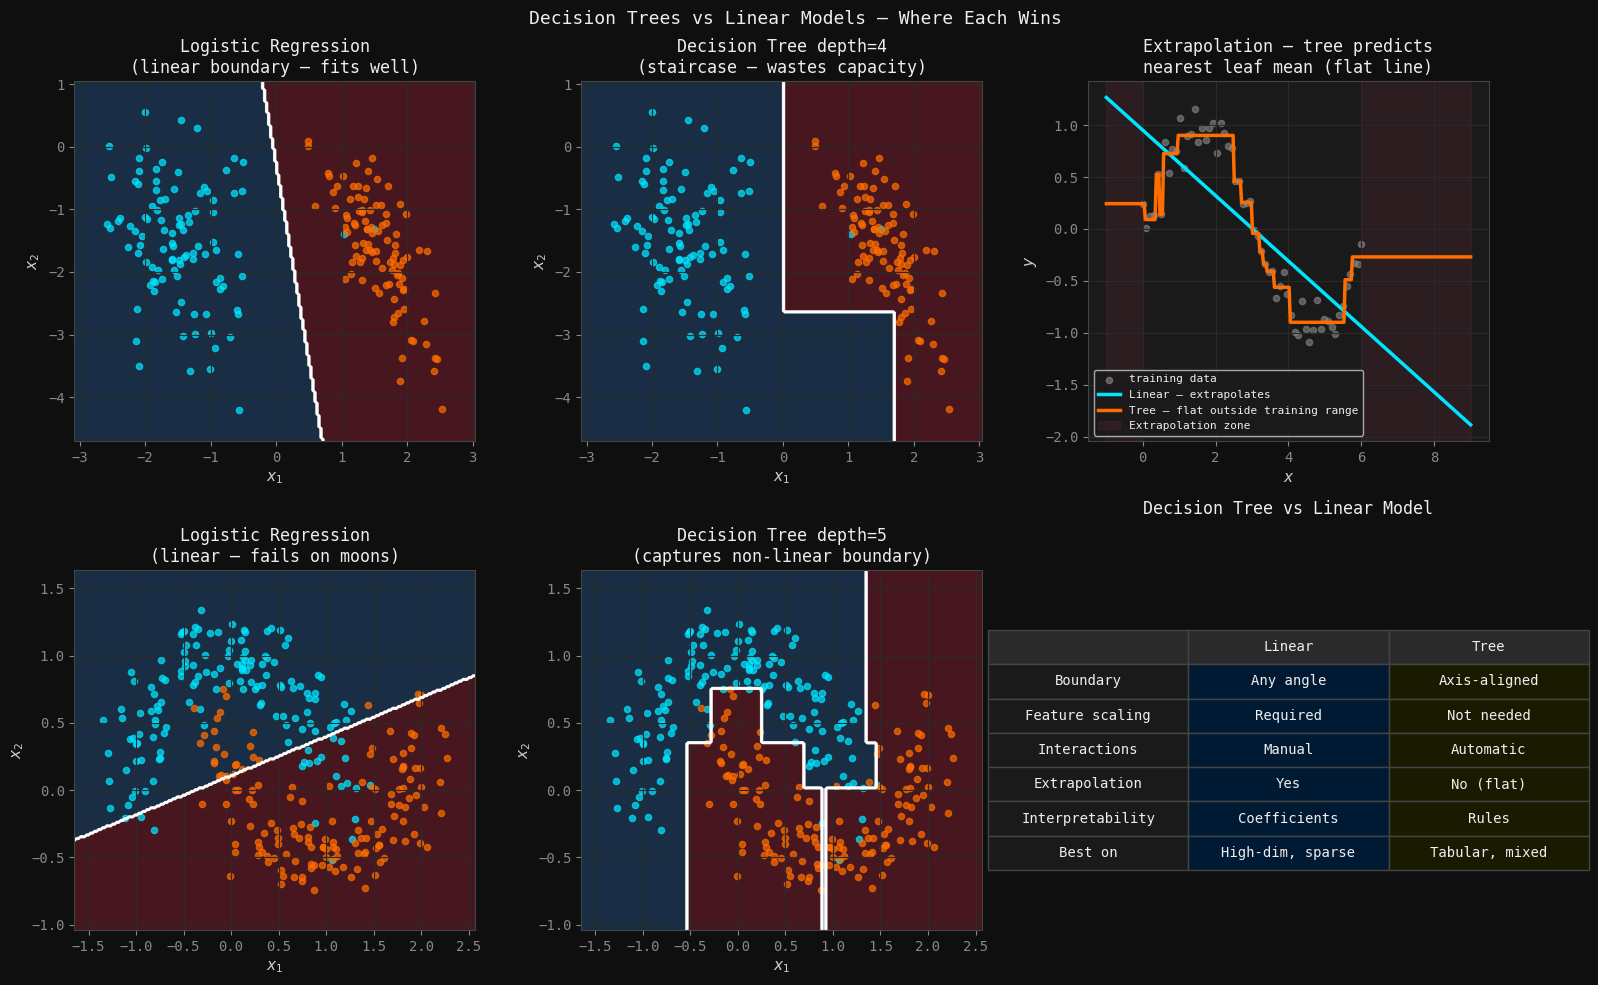

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

np.random.seed(5)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Decision Trees vs Linear Models — Where Each Wins', fontsize=13)

# Case 1: linear boundary — logistic wins
np.random.seed(5)
X_lin, y_lin = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                     n_informative=2, n_clusters_per_class=1,
                                     class_sep=1.5, random_state=5)
xx_l, yy_l = np.meshgrid(np.linspace(X_lin[:,0].min()-0.5, X_lin[:,0].max()+0.5, 200),
                           np.linspace(X_lin[:,1].min()-0.5, X_lin[:,1].max()+0.5, 200))
X_ls = StandardScaler().fit_transform(X_lin)

for ax, clf, title in zip(
    axes[0][:2],
    [LogisticRegression().fit(X_ls, y_lin),
     DecisionTreeClassifier(max_depth=4).fit(X_lin, y_lin)],
    ['Logistic Regression\n(linear boundary — fits well)', 'Decision Tree depth=4\n(staircase — wastes capacity)']):
    if hasattr(clf, 'predict_proba'):
        try:
            Xs_grid = StandardScaler().fit(X_lin).transform(np.c_[xx_l.ravel(), yy_l.ravel()])
            Z_l = clf.predict(Xs_grid).reshape(xx_l.shape)
        except:
            Z_l = clf.predict(np.c_[xx_l.ravel(), yy_l.ravel()]).reshape(xx_l.shape)
    else:
        Z_l = clf.predict(np.c_[xx_l.ravel(), yy_l.ravel()]).reshape(xx_l.shape)
    ax.contourf(xx_l, yy_l, Z_l, alpha=0.35, cmap='RdBu_r')
    ax.contour(xx_l,  yy_l, Z_l, colors='white', linewidths=1.2, alpha=0.7)
    ax.scatter(X_lin[y_lin==0,0], X_lin[y_lin==0,1], color=ACCENT, s=20, alpha=0.7)
    ax.scatter(X_lin[y_lin==1,0], X_lin[y_lin==1,1], color=ORANGE, s=20, alpha=0.7)
    ax.set_title(title); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

# Case 2: XOR / interaction — tree wins
np.random.seed(2)
X_xor2, y_xor2 = make_moons(n_samples=300, noise=0.2, random_state=2)
xx_x, yy_x = np.meshgrid(np.linspace(X_xor2[:,0].min()-0.3, X_xor2[:,0].max()+0.3, 200),
                           np.linspace(X_xor2[:,1].min()-0.3, X_xor2[:,1].max()+0.3, 200))
X_xs = StandardScaler().fit_transform(X_xor2)

for ax, (clf, Xg), title in zip(
    axes[1][:2],
    [(LogisticRegression().fit(X_xs, y_xor2),
      StandardScaler().fit(X_xor2).transform(np.c_[xx_x.ravel(), yy_x.ravel()])),
     (DecisionTreeClassifier(max_depth=5).fit(X_xor2, y_xor2),
      np.c_[xx_x.ravel(), yy_x.ravel()])],
    ['Logistic Regression\n(linear — fails on moons)', 'Decision Tree depth=5\n(captures non-linear boundary)']):
    Z_x = clf.predict(Xg).reshape(xx_x.shape)
    ax.contourf(xx_x, yy_x, Z_x, alpha=0.35, cmap='RdBu_r')
    ax.contour(xx_x,  yy_x, Z_x, colors='white', linewidths=1.2, alpha=0.7)
    ax.scatter(X_xor2[y_xor2==0,0], X_xor2[y_xor2==0,1], color=ACCENT, s=20, alpha=0.7)
    ax.scatter(X_xor2[y_xor2==1,0], X_xor2[y_xor2==1,1], color=ORANGE, s=20, alpha=0.7)
    ax.set_title(title); ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$'); ax.grid(True)

# Extrapolation comparison
ax = axes[0][2]
np.random.seed(1)
x_ex = np.linspace(0, 6, 60)
y_ex = np.sin(x_ex) + np.random.randn(60)*0.15
X_ex = x_ex.reshape(-1,1)
x_full = np.linspace(-1, 9, 300).reshape(-1,1)

reg_lr = LogisticRegression()  # will use linear regression instead
from sklearn.linear_model import LinearRegression
reg_lin = LinearRegression().fit(X_ex, y_ex)
reg_dt  = DecisionTreeRegressor(max_depth=4).fit(X_ex, y_ex)

ax.scatter(x_ex, y_ex, color='#888', s=20, alpha=0.6, label='training data')
ax.plot(x_full, reg_lin.predict(x_full), color=ACCENT,  lw=2.5, label='Linear — extrapolates')
ax.plot(x_full, reg_dt.predict(x_full),  color=ORANGE, lw=2.5, label='Tree — flat outside training range')
ax.axvspan(-1, 0,  alpha=0.08, color=RED, label='Extrapolation zone')
ax.axvspan(6,  9,  alpha=0.08, color=RED)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Extrapolation — tree predicts\nnearest leaf mean (flat line)')
ax.legend(fontsize=8); ax.grid(True)

# Summary table
ax = axes[1][2]
ax.axis('off')
table_data = [
    ['', 'Linear', 'Tree'],
    ['Boundary', 'Any angle', 'Axis-aligned'],
    ['Feature scaling', 'Required', 'Not needed'],
    ['Interactions', 'Manual', 'Automatic'],
    ['Extrapolation', 'Yes', 'No (flat)'],
    ['Interpretability', 'Coefficients', 'Rules'],
    ['Best on', 'High-dim, sparse', 'Tabular, mixed'],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.5, 2.0)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2a2a2a')
    elif c == 1:
        cell.set_facecolor('#001a33')
    elif c == 2:
        cell.set_facecolor('#1a1a00')
    else:
        cell.set_facecolor('#1a1a1a')
    cell.set_edgecolor('#444')
    cell.set_text_props(color='#eee')
ax.set_title('Decision Tree vs Linear Model', pad=40)

plt.tight_layout()
plt.savefig('img/dt08_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Key Takeaways

1. A decision tree partitions feature space into **axis-aligned rectangles** by greedily maximising impurity reduction at each split. It is a greedy algorithm — no backtracking, no global optimality guarantee.
2. **Gini** $= 1 - \sum p_c^2$ and **Entropy** $= -\sum p_c \log_2 p_c$ measure the same thing (node impurity) with different formulas. Both peak at uniform class distribution and hit 0 at purity. In practice, they produce near-identical trees.
3. **Information Gain** $= H(\text{parent}) - \sum_k \frac{n_k}{n} H(k)$ is always $\geq 0$. The best split is the one that maximises IG — equivalently, minimises the weighted child entropy.
4. For regression, **variance reduction** replaces entropy — and minimising leaf variance is exactly minimising training MSE.
5. Fully grown trees **memorise** training data. Depth control (`max_depth`, `min_samples_leaf`) and cost-complexity pruning (`ccp_alpha`) are the primary tools for regularisation.
6. **MDI feature importance** is a by-product of training but is biased toward high-cardinality features. **Permutation importance** on the test set is more reliable.
7. Trees require **no feature scaling**, handle **categorical features** naturally, capture **interactions automatically** — but cannot extrapolate and produce a staircase decision boundary that is wasteful on linearly separable problems.

---
*Previous: [`04_neural_networks_backprop.ipynb`](./04_neural_networks_backprop.ipynb) · Next: [`06_xgboost.ipynb`](./06_xgboost.ipynb)*